# Agents: easy to start, hard to stop

Building an agent loop is trivial — LLM calls tools in a while loop until it decides to stop. The hard part is *when does it stop?*

This notebook runs the same LangGraph loop on four tasks to see how different exit conditions behave:
1. **Sequential math** — deterministic, runs out of instructions
2. **Constraint sat. (solution exists)** — model finds answer and stops
3. **Constraint sat. (no solution)** — model can't prove absence, spins until `recursion_limit`
4. **Search** — model makes a judgment call on "good enough"

Takeaway: the loop is not the problem. The exit condition is.

In [1]:
%%capture --no-stderr
%pip install --quiet -U ipython langchain-core langgraph langgraph-prebuilt langchain-google-genai langchain-community duckduckgo-search

In [2]:
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

from helpers import set_env, print_stats, print_summary

set_env('GOOGLE_API_KEY')

run_stats = []
task_stats = {}

In [3]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

In [4]:
def add(a: int, b: int) -> int:
    """Adds a and b."""
    return a + b

def multiply(a: int, b: int) -> int:
    """Multiplies a and b."""
    return a * b

def divide(a: int, b: int) -> float:
    """Divides a by b."""
    return a / b

arithmetic_tools = [add, multiply, divide]

search_tool = DuckDuckGoSearchRun()
search_tools = [search_tool]

In [5]:
sys_msg_math = SystemMessage(
    content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.'
)

sys_msg_search = SystemMessage(
    content=(
        'You are a research assistant. Use search to find accurate, up-to-date information. '
        'Search as many times as needed until you are confident in your answer.'
    )
)

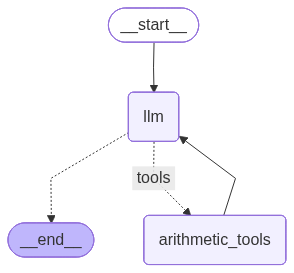

In [6]:
llm_math = llm.bind_tools(arithmetic_tools)

def math_llm_node(state: MessagesState):
    response = llm_math.invoke([sys_msg_math] + state['messages'])
    run_stats.append({
        'loop': len(run_stats) + 1,
        'input_tokens': response.usage_metadata['input_tokens'],
        'output_tokens': response.usage_metadata['output_tokens'],
        'tool_call': bool(response.tool_calls),
        'calls': [{'name': c['name'], 'args': c['args']} for c in response.tool_calls],
    })
    return {'messages': [response]}

math_builder = StateGraph(MessagesState)
math_builder.add_node('llm', math_llm_node)
math_builder.add_node('arithmetic_tools', ToolNode(arithmetic_tools))
math_builder.add_edge(START, 'llm')
math_builder.add_conditional_edges('llm', tools_condition, {'tools': 'arithmetic_tools', END: END})
math_builder.add_edge('arithmetic_tools', 'llm')
math_graph = math_builder.compile()

display(Image(math_graph.get_graph(xray=True).draw_mermaid_png()))

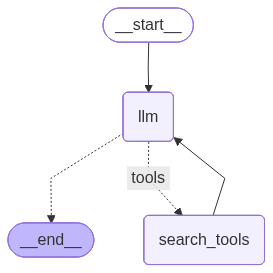

In [7]:
llm_search = llm.bind_tools(search_tools)

def search_llm_node(state: MessagesState):
    response = llm_search.invoke([sys_msg_search] + state['messages'])
    run_stats.append({
        'loop': len(run_stats) + 1,
        'input_tokens': response.usage_metadata['input_tokens'],
        'output_tokens': response.usage_metadata['output_tokens'],
        'tool_call': bool(response.tool_calls),
        'query': response.tool_calls[0]['args'].get('query', '') if response.tool_calls else '',
    })
    return {'messages': [response]}

search_builder = StateGraph(MessagesState)
search_builder.add_node('llm', search_llm_node)
search_builder.add_node('search_tools', ToolNode(search_tools))
search_builder.add_edge(START, 'llm')
search_builder.add_conditional_edges('llm', tools_condition, {'tools': 'search_tools', END: END})
search_builder.add_edge('search_tools', 'llm')
search_graph = search_builder.compile()

display(Image(search_graph.get_graph(xray=True).draw_mermaid_png()))

---

## The raw while loop

What LangGraph actually does under the hood:
- `add_edge('tools', 'llm')` = loop back
- `tools_condition` = exit check
- `MessagesState` = accumulating context

In [8]:
def run_agent_raw(task: str, max_iterations: int = 10):
    messages = [HumanMessage(content=task)]
    stats = []
    tool_map = {t.__name__: t for t in arithmetic_tools}

    for i in range(max_iterations):
        response = llm_math.invoke([sys_msg_math] + messages)
        stats.append({
            'loop': i + 1,
            'input_tokens': response.usage_metadata['input_tokens'],
            'output_tokens': response.usage_metadata['output_tokens'],
            'tool_call': bool(response.tool_calls),
        })
        messages.append(response)

        if not response.tool_calls:
            break

        for call in response.tool_calls:
            result = tool_map[call['name']](**call['args'])
            messages.append(ToolMessage(content=str(result), tool_call_id=call['id']))

    return messages, stats

msgs_raw, stats_raw = run_agent_raw("Add 3 and 4. Multiply the output by 2. Divide the output by 5.")
print_stats(stats_raw, answer=msgs_raw[-1].content)

Loop   In       Out      Tool?   Details
----------------------------------------
1      196      16       Y       —
2      222      16       Y       —
3      249      17       Y       —
4      278      9        —       —

Total tokens: 1003
Answer: [{'type': 'text', 'text': 'The final result is 2.8.', 'extras': {'signature': 'EjQKMgG+Pvb7iIvjqBj3P/ZMcvR7n1kedleWW0TLHpzzxriEiimvJqAZ0s+TVkUQ9zKSRnDI'}}]


---

## Experiments

Same loop, four tasks. Only the exit condition changes — that's the whole problem.

| Task | Exit condition |
|------|----------------|
| Sequential math | Deterministic — runs out of steps |
| Constraint sat. (has solution) | Model finds answer, stops |
| Constraint sat. (no solution) | Never converges |
| Search | Model decides "good enough" |

### Task 1 — Sequential math

Baseline. Three steps, obvious done state. A chain would be cheaper here — agent is overkill.

In [9]:
run_stats.clear()
task_1 = "Add 3 and 4. Multiply the output by 2. Divide the output by 5."
result_1 = math_graph.invoke({'messages': [HumanMessage(content=task_1)]})
task_stats[1] = run_stats.copy()

print_stats(task_stats[1], answer=result_1['messages'][-1].content)

Loop   In       Out      Tool?   Details
----------------------------------------
1      196      16       Y       add({'a': 3, 'b': 4})
2      222      16       Y       multiply({'a': 7, 'b': 2})
3      249      17       Y       divide({'a': 14, 'b': 5})
4      278      9        —       —

Total tokens: 1003
Answer: [{'type': 'text', 'text': 'The final result is 2.8.', 'extras': {'signature': 'EjQKMgG+Pvb7Isv8AnhPP9dF3V4Svp5aT5rsaaMT1PPAmnEFVWy8iZKW2R/98H+bOx47qpZI'}}]


### Task 2 — Constraint satisfaction (solution exists)

Find two positive integers that multiply to 84 and add to 25. (answer: 4 and 21)

Non-deterministic loop count — model guesses, verifies, backtracks.

In [10]:
run_stats.clear()
task_2 = (
    'Find two positive integers that multiply to 84 and add to 25. '
    'Use only the multiply and add tools to check your candidates. '
    'Try specific number pairs and verify each one.'
)
result_2 = math_graph.invoke(
    {'messages': [HumanMessage(content=task_2)]},
    config={'recursion_limit': 40}
)
task_stats[2] = run_stats.copy()

print_stats(task_stats[2], answer=result_2['messages'][-1].content)

Loop   In       Out      Tool?   Details
----------------------------------------
1      213      34       Y       multiply({'a': 21, 'b': 4}), add({'a': 21, 'b': 4})
2      267      60       —       —

Total tokens: 574
Answer: [{'type': 'text', 'text': 'The two positive integers that multiply to 84 and add to 25 are 21 and 4.\n\n**Verification:**\n*   **Multiply:** 21 * 4 = 84\n*   **Add:** 21 + 4 = 25', 'extras': {'signature': 'EjQKMgG+Pvb7DU8y2MLvm4sFM6W5S0cC5auqmfCimdwSwF0sAzMUwCuYtZiKaukqgcZGnvMT'}}]


### Task 3 — Constraint satisfaction (no solution)

Same problem but sum=24. No factor pair of 84 adds to 24. Model can't prove absence — no exhaustive enumeration tool. `recursion_limit` is the only backstop.

In [11]:
run_stats.clear()
task_3 = (
    'Find two positive integers that multiply to 84 and add to 24. '
    'Use only the multiply and add tools to check your candidates. '
    'Try specific number pairs and verify each one.'
)
try:
    result_3 = math_graph.invoke(
        {'messages': [HumanMessage(content=task_3)]},
        config={'recursion_limit': 40}
    )
    hit_limit = False
except Exception:
    hit_limit = True
    result_3 = None
task_stats[3] = run_stats.copy()

print(f'Hit recursion limit: {hit_limit}  |  Loops: {len(task_stats[3])}')

print(f"\n{'Loop':<6} {'Tool calls'}")
print('-' * 65)
for s in task_stats[3]:
    if s['calls']:
        calls_str = '  |  '.join(
            f"{c['name']}({', '.join(str(v) for v in c['args'].values())})"
            for c in s['calls']
        )
    else:
        calls_str = '(stopped)'
    print(f"{s['loop']:<6} {calls_str}")

total_3 = sum(s['input_tokens'] + s['output_tokens'] for s in task_stats[3])
print(f'\nTotal tokens: {total_3}')

Hit recursion limit: False  |  Loops: 11

Loop   Tool calls
-----------------------------------------------------------------
1      multiply(6, 18)  |  add(6, 18)  |  multiply(8, 16)  |  add(8, 16)  |  multiply(10, 14)  |  add(10, 14)  |  multiply(12, 12)  |  add(12, 12)
2      multiply(6, 14)  |  add(6, 14)  |  multiply(17, 7)  |  add(17, 7)
3      add(20, 4)  |  multiply(20, 4)
4      add(21, 3)  |  multiply(21, 3)
5      add(5, 19)  |  multiply(5, 19)
6      add(22, 2)  |  multiply(22, 2)
7      add(8, 16)
8      add(9, 15)  |  multiply(9, 15)
9      add(10, 14)
10     add(11, 13)  |  multiply(11, 13)
11     (stopped)

Total tokens: 8104


In [12]:
# context compounds — full message history resent every loop
print(f"{'Loop':<6} {'Input tokens':<16} {'Delta'}")
print('-' * 40)
prev = 0
for s in task_stats[3]:
    delta = f'+{s["input_tokens"] - prev}' if prev else '—'
    print(f"{s['loop']:<6} {s['input_tokens']:<16} {delta}")
    prev = s['input_tokens']

first, last = task_stats[3][0]['input_tokens'], task_stats[3][-1]['input_tokens']
print(f'\nGrowth: {first} -> {last} ({last/first:.1f}x). With search results this blows up faster.')

Loop   Input tokens     Delta
----------------------------------------
1      213              —
2      431              +218
3      538              +107
4      592              +54
5      646              +54
6      700              +54
7      754              +54
8      782              +28
9      837              +55
10     866              +29
11     923              +57

Growth: 213 -> 923 (4.3x). With search results this blows up faster.


#### Does it always hit the limit?

Run it 5 times. When it exits early, check: did it correctly say "no solution" or did it hallucinate an answer?

In [13]:
task3_runs = []
for i in range(5):
    run_stats.clear()
    try:
        r = math_graph.invoke(
            {'messages': [HumanMessage(content=task_3)]},
            config={'recursion_limit': 40}
        )
        hit = False
        answer = str(r['messages'][-1].content)[:150]
    except Exception:
        hit = True
        answer = '(hit limit — no final message)'
    s = run_stats.copy()
    task3_runs.append({
        'run': i + 1,
        'loops': len(s),
        'tokens': sum(x['input_tokens'] + x['output_tokens'] for x in s),
        'hit_limit': hit,
        'answer': answer,
    })

for r in task3_runs:
    status = 'HIT LIMIT' if r['hit_limit'] else 'exited early'
    print(f"Run {r['run']}: {r['loops']:>2} loops  {r['tokens']:>6} tokens  [{status}]")
    if not r['hit_limit']:
        print(f"         → {r['answer']}")

hit_count = sum(1 for r in task3_runs if r['hit_limit'])
print(f'\n{hit_count}/5 runs hit recursion_limit')
if hit_count < 5:
    print('The rest exited early — the model gave an answer despite no solution existing.')
    print('Hallucination and hitting the limit are both exit condition failures.')
else:
    print('All runs hit the limit. The model never admitted there was no solution.')

Run 1: 13 loops    7670 tokens  [exited early]
         → [{'type': 'text', 'text': 'Actually, after reviewing the problem and checking various pairs that sum to 24, there are no two positive integers that mu
Run 2: 20 loops   17137 tokens  [HIT LIMIT]
Run 3: 20 loops   11073 tokens  [HIT LIMIT]
Run 4:  9 loops    4941 tokens  [exited early]
         → [{'type': 'text', 'text': "To find two positive integers that multiply to 84 and add to 24, let's analyze the factors of 84. The factor pairs of 84 ar
Run 5: 20 loops   10068 tokens  [HIT LIMIT]

3/5 runs hit recursion_limit
The rest exited early — the model gave an answer despite no solution existing.
Hallucination and hitting the limit are both exit condition failures.


### Task 4 — Search

Exit condition is "I know enough" — a vibes check. System prompt controls how aggressive/conservative the model is about stopping.

In [14]:
run_stats.clear()
task_4 = (
    'Which AI model currently holds the top spot on the HumanEval coding benchmark? '
    'Is it from OpenAI, Anthropic, Google, or someone else? '
    "Search until you're confident, then give me a definitive answer with your source."
)
result_4 = search_graph.invoke(
    {'messages': [HumanMessage(content=task_4)]},
    config={'recursion_limit': 20}
)
task_stats[4] = run_stats.copy()

print_stats(task_stats[4], answer=result_4['messages'][-1].content)

Loop   In       Out      Tool?   Details
----------------------------------------
1      156      25       Y       query: current top AI model HumanEval benchmark leaderboard
2      491      35       Y       query: what model has the highest HumanEval score 2024 2025
3      768      30       Y       query: "HumanEval" benchmark highest score model 2025
4      1069     31       Y       query: is HumanEval saturated? can models score 100%?
5      1359     402      —       —

Total tokens: 4366
Answer: [{'type': 'text', 'text': 'The **HumanEval** benchmark is widely considered to be **saturated**. Because top-tier frontier models from major labs (such as OpenAI, Anthropic, Google, and others) frequently score above 90%—often clustering between 90% and 96%—the benchmark is no longer capable of meaningfully distinguishing between the best-performing models.\n\nBecause of this saturation, there is no single, undisputed "top" model. Instead, several models from leading labs effectively share 

---

### Summary

In [15]:
print_summary(task_stats)

Task                               Loops   Tokens   Cost         Exit
---------------------------------------------------------------------
Sequential math                    4       1003     $0.000088   Deterministic
Constraint sat. (solution)         2       574      $0.000064   Model finds answer
Constraint sat. (no solution)      11      8104     $0.000793   Never converges
Search (ambiguous)                 5       4366     $0.000445   Model decides

No-solution task used 14.1x the tokens of the solution task.
